In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18
from sklearn.linear_model import Lasso
import torch.nn.functional as F

In [91]:
def load_image(path):
    img = Image.open(path).convert('RGB')
    return img.resize((224, 224))

def kmeans_numpy(X, n_clusters, max_iter=100, tol=1e-4):
    n = X.shape[0]
    # Randomly choose initial centroids from the data
    idx = np.random.choice(n, size=n_clusters, replace=False)
    centroids = X[idx].copy()
    labels = np.zeros(n, dtype=np.int32)
    for it in range(max_iter):
        # Assign each point to nearest centroid
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)  # (n, k)
        new_labels = np.argmin(dists, axis=1)
        # Update centroids
        new_centroids = np.array([X[new_labels == j].mean(axis=0) 
                                  for j in range(n_clusters)])
        # If a cluster is empty, re‑initialize its centroid randomly
        for j in range(n_clusters):
            if not np.any(new_labels == j):
                new_centroids[j] = X[np.random.choice(n)]
        # Check convergence
        if np.allclose(centroids, new_centroids, atol=tol):
            labels = new_labels
            centroids = new_centroids
            break
        centroids = new_centroids
        labels = new_labels
    return centroids, labels


def kmeans_segments(image_uint8, n_segments=64, max_iter=50):
    H, W = image_uint8.shape[:2]
    xs, ys = np.meshgrid(np.arange(W), np.arange(H))
    features = np.column_stack([
        image_uint8.reshape(-1, 3).astype(float),
        ys.ravel().astype(float) * (255.0 / H) ,
        xs.ravel().astype(float) * (255.0 / W)
    ])
    centroids, labels = kmeans_numpy(features, n_segments, 
                                     max_iter=max_iter)
    return labels.reshape(H, W)

In [ ]:
MODEL_PATH = r"..\..\Model Weights (Q1 & Q2)\resnet18-f37072fd.pth"  
np.random.seed(42)          
torch.manual_seed(42)      

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Load model architecture and weights
model = resnet18(weights=None)   
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded from", MODEL_PATH)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Using device: cpu
Model loaded from ..\..\Model Weights (Q1 & Q2)\resnet18-f37072fd.pth


*** ***

In [93]:
def prediction_for_special_class(image, class_index):
    tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        model_logits = model(tensor)
        probabilities = F.softmax(model_logits, dim=1)
    probability = probabilities[0, class_index].item()
    return probability

In [94]:
CAT_IMAGE_PATH = "cat.jpg"
CAT_CLASS_INDEX = 282
cat_image = load_image(CAT_IMAGE_PATH)
cat_probability = prediction_for_special_class(cat_image, CAT_CLASS_INDEX)
print(f"Probability for class cat: {cat_probability:.6f}")

Probability for class cat: 0.905519


*** ***

In [95]:
NUMBER_OF_SEGMENTS = 18

In [96]:
def plot_segmented_image(original_image, segments):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(segments, cmap='nipy_spectral')
    plt.title("Segmentation Image")
    plt.axis('off')
    plt.show()

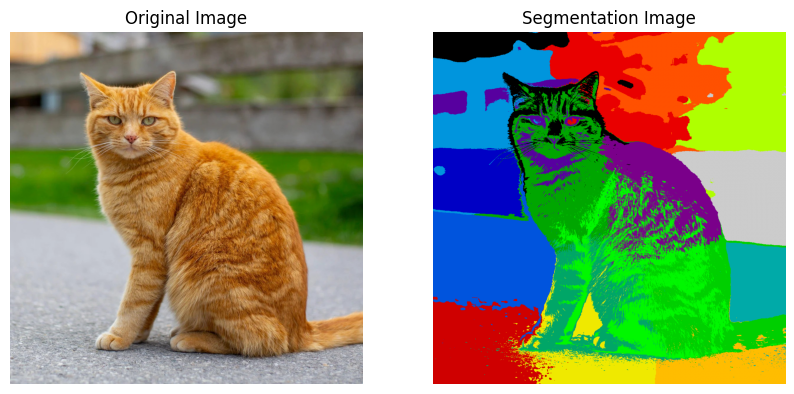

In [97]:
original_cat_image = np.array(Image.open(CAT_IMAGE_PATH).convert('RGB'))
segments = kmeans_segments(original_cat_image, n_segments=NUMBER_OF_SEGMENTS)
plot_segmented_image(original_cat_image, segments)

*** ***

In [98]:
NUMBER_OF_SAMPLE = 1000
Z = np.random.randint(0, 2, size=(NUMBER_OF_SAMPLE, NUMBER_OF_SEGMENTS))

In [114]:
def perturb_image(image, segments, z):
    mean_color = image.reshape(-1, 3).mean(axis=0)
    perturbed_image = image.copy()
    for i in range(len(z)):
        if z[i] == 0:
            mask = (segments == i)
            perturbed_image[mask] = mean_color
    return perturbed_image

In [ ]:
def plot_perturbed_images(original_image, segments):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    for i in range(8):
        z = Z[i]
        perturbed_image = perturb_image(original_image, segments, z)
        axes[i].imshow(perturbed_image)
        axes[i].set_title(f"z sum = {sum(z)}/18")
        axes[i].axis('off')
    fig.suptitle("Example Perturbed Images", fontsize=16)
    plt.tight_layout()
    plt.show()

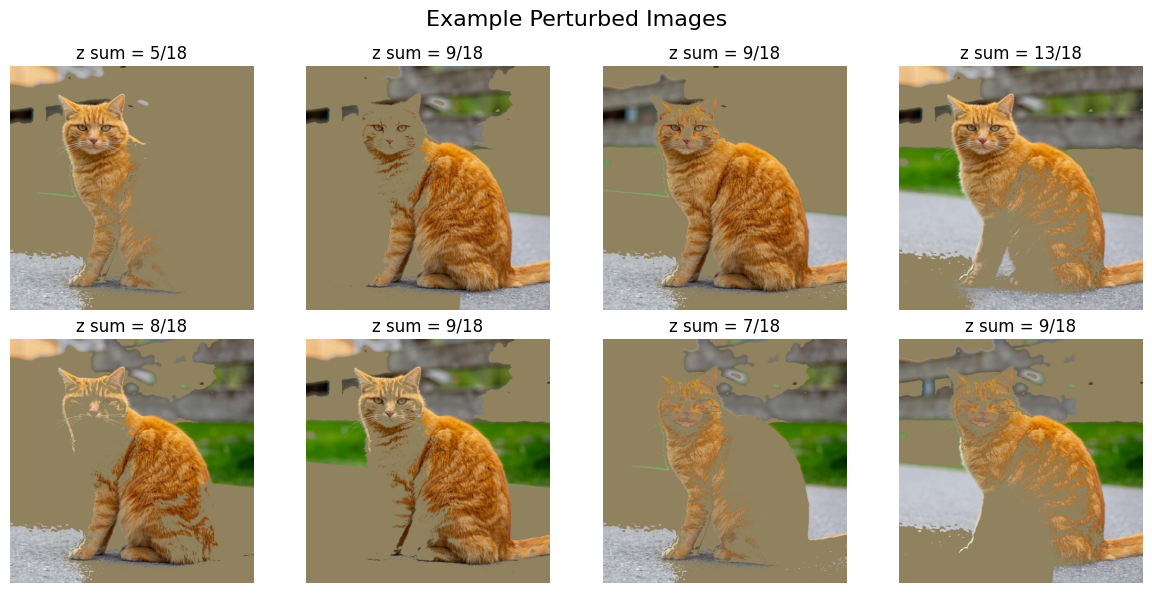

In [101]:
plot_perturbed_images(original_cat_image, segments)

*** ***

In [102]:
def calculate_weights(Z, sigma):
    number_of_dimentions = Z.shape[1]
    ones_vector = np.ones(number_of_dimentions)
    epsilon = 1e-10
    Z_norm = np.linalg.norm(Z, axis=1)
    ones_norm = np.linalg.norm(ones_vector)
    dist_Z = 1 - ((np.dot(Z, ones_vector))/ (Z_norm * ones_norm + epsilon))
    weights_Z = np.exp(-(dist_Z**2)/(sigma**2))
    return weights_Z

In [103]:
sigma = 0.25 * np.sqrt(NUMBER_OF_SEGMENTS)
weights_Z = calculate_weights(Z, sigma)
print(f"Average weight: {np.mean(weights_Z):.4f}")

Average weight: 0.9213


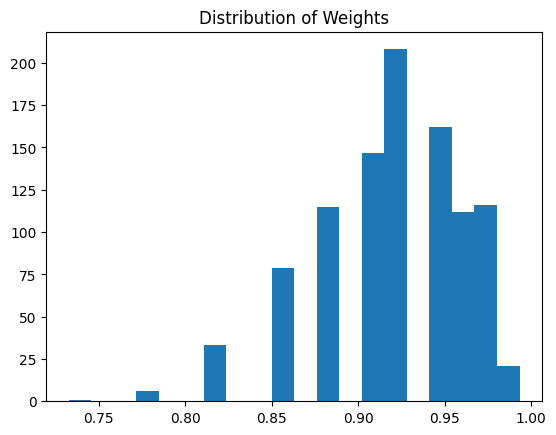

In [104]:
plt.hist(weights_Z, bins=20)
plt.title("Distribution of Weights")
plt.show()

*** ***

In [ ]:
def get_predictions(Z, original_image, segments, model, device, transform, class_index):
    model.eval()
    predictions = []
    for z in Z:
        perturbed_image = perturb_image(original_image, segments, z)
        input_tensor = transform(perturbed_image).unsqueeze(0).to(device)
        with torch.no_grad():
            model_logits = model(input_tensor)
            probability_target = model_logits[0, class_index].item()
        predictions.append(probability_target)
    return np.array(predictions)

In [106]:
y_prediction = get_predictions(Z, original_cat_image, segments, model, device, transform, CAT_CLASS_INDEX)
lasso_model = Lasso(alpha=0.1, fit_intercept=False)
lasso_model.fit(Z, y_prediction, sample_weight=weights_Z)
coefficients = lasso_model.coef_

In [107]:
print("coef min/max:", coefficients.min(), coefficients.max())
print("non-zero:", np.sum(np.abs(coefficients) > 1e-6), "out of", len(coefficients))
print("first 10:", coefficients[:10])

coef min/max: 0.0 0.5607399327487532
non-zero: 12 out of 18
first 10: [0.46969902 0.24765175 0.2406232  0.00887607 0.         0.
 0.         0.20661017 0.46553733 0.1019396 ]


In [108]:
print("unique segments:", np.unique(segments))
print("num unique segments:", len(np.unique(segments)))
print("len(coefficients):", len(coefficients))


unique segments: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
num unique segments: 18
len(coefficients): 18


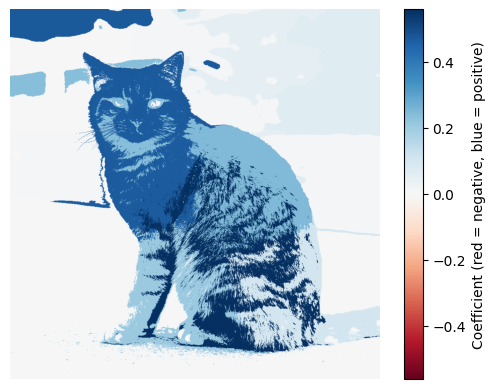

In [109]:
def plot_heatmap(coefficients, segments):
    heatmap = np.zeros(segments.shape)
    for i, coef in enumerate(coefficients):
        heatmap[segments == i] = coef
        
    plt.imshow(heatmap, cmap='RdBu', vmin=-max(abs(coefficients)), vmax=max(abs(coefficients)))
    plt.colorbar(label='Coefficient (red = negative, blue = positive)')
    plt.axis('off')
    plt.show()

plot_heatmap(coefficients, segments)

*** ***

In [110]:
POLAR_BEAR_IMAGE_PATH = "polarBear.png"
POLAR_BEAR_CLASS_INDEX = 296
polar_bear_image = load_image(POLAR_BEAR_IMAGE_PATH)
polar_bear_probability = prediction_for_special_class(polar_bear_image, POLAR_BEAR_CLASS_INDEX)
print(f"Probability for class polar bear: {polar_bear_probability:.6f}")

Probability for class polar bear: 0.996435


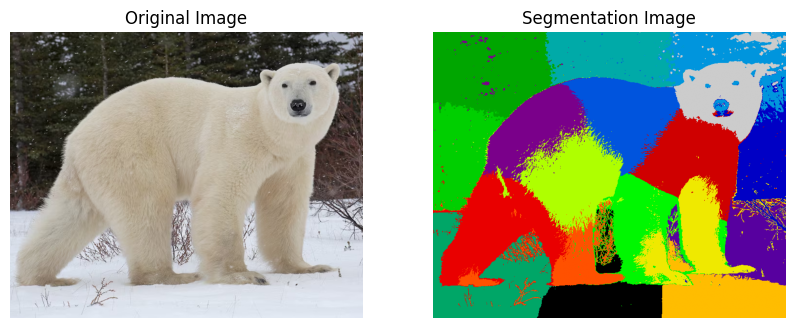

In [111]:
original_polar_bear_image = np.array(Image.open(POLAR_BEAR_IMAGE_PATH).convert('RGB'))
polar_bear_segments = kmeans_segments(original_polar_bear_image, n_segments=NUMBER_OF_SEGMENTS)
plot_segmented_image(original_polar_bear_image, polar_bear_segments)

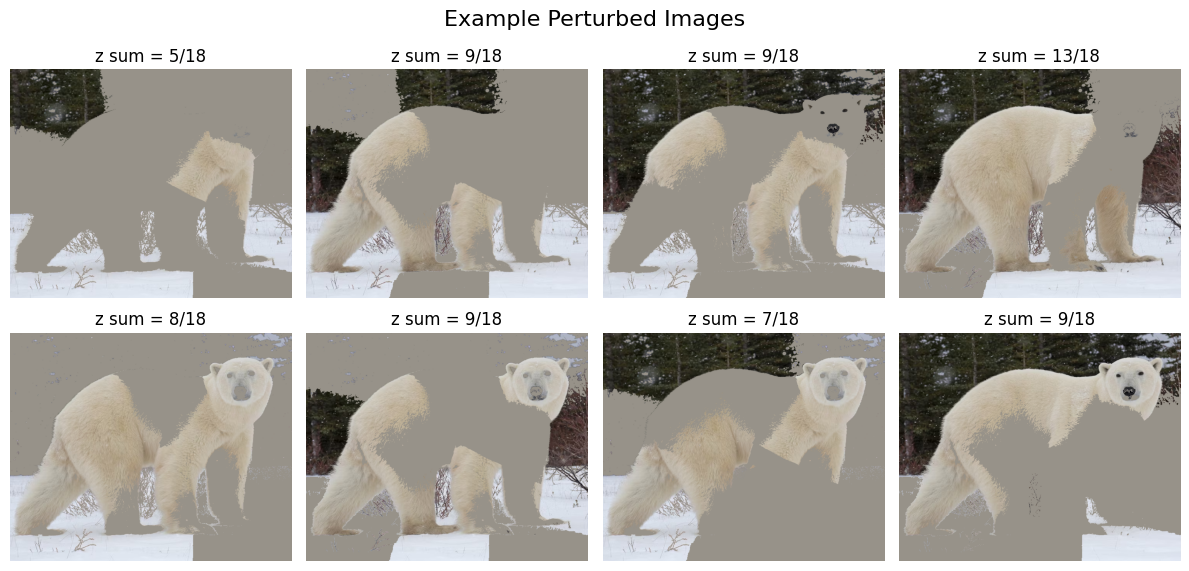

In [112]:
plot_perturbed_images(original_polar_bear_image, polar_bear_segments)

In [115]:
y_prediction = get_predictions(Z, original_polar_bear_image, polar_bear_segments, model, device, transform, POLA_RBEAR_CLASS_INDEX)
lasso_model = Lasso(alpha=0.1, fit_intercept=False)
lasso_model.fit(Z, y_prediction, sample_weight=weights_Z)
coefficients = lasso_model.coef_

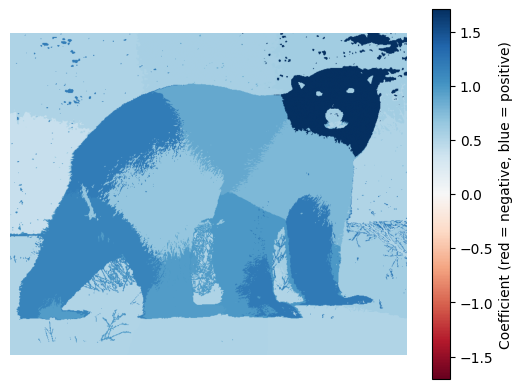

In [116]:
plot_heatmap(coefficients, polar_bear_segments)